# Introdução

Este projeto visa analisar a evolução das temperaturas médias globais por país ao longo dos anos, utilizando dados da FAO (Food and Agriculture Organization). Serão exploradas variações por país, tendências históricas, tratamento de dados ausentes e outliers, além da criação de novas features para alimentar modelos de machine learning.


In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Carregando o dataset
df = pd.read_csv("../data/Environment_Temperature_change_E_All_Data_NOFLAG.csv", encoding="ISO-8859-1")

# Renomeando colunas
df.columns = df.columns.str.replace("ï»¿", "")

# Filtrando apenas temperatura média anual
df = df[df["Element"] == "Temperature change"]

# Convertendo de wide para long
df_long = df.melt(
    id_vars=["Area", "Months", "Element", "Unit"],
    value_vars=[col for col in df.columns if col.startswith("Y")],
    var_name="Year",
    value_name="Value"
)

df_long["Year"] = df_long["Year"].str.extract("(\d+)").astype(int)
df_long["Value"] = pd.to_numeric(df_long["Value"], errors="coerce")
df_long.dropna(subset=["Value"], inplace=True)

df_long.head()


,Area,Months,Element,Unit,Year,Value
0,Afghanistan,January,Temperature change,°C,1961,0.777
1,Afghanistan,February,Temperature change,°C,1961,-1.743
2,Afghanistan,March,Temperature change,°C,1961,0.516
3,Afghanistan,April,Temperature change,°C,1961,-1.709
4,Afghanistan,May,Temperature change,°C,1961,1.412


# Análise Exploratória (EDA)

Nesta etapa, analisamos as distribuições dos dados, tendências temporais e variações regionais.


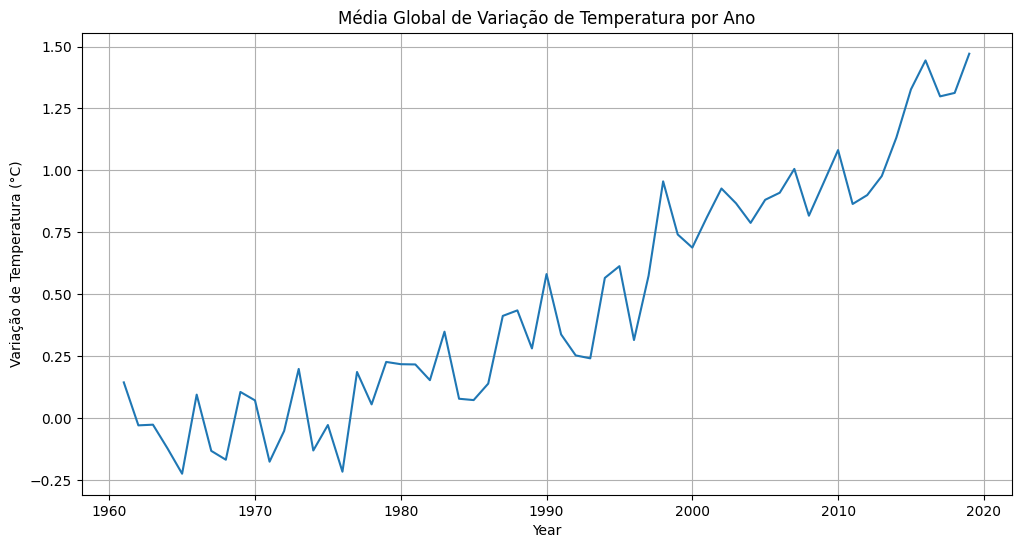

In [23]:
# Temperatura média global por ano
media_anual = df_long.groupby("Year")["Value"].mean()

plt.figure(figsize=(12, 6))
sns.lineplot(x=media_anual.index, y=media_anual.values)
plt.title("Média Global de Variação de Temperatura por Ano")
plt.ylabel("Variação de Temperatura (°C)")
plt.grid()
plt.show()


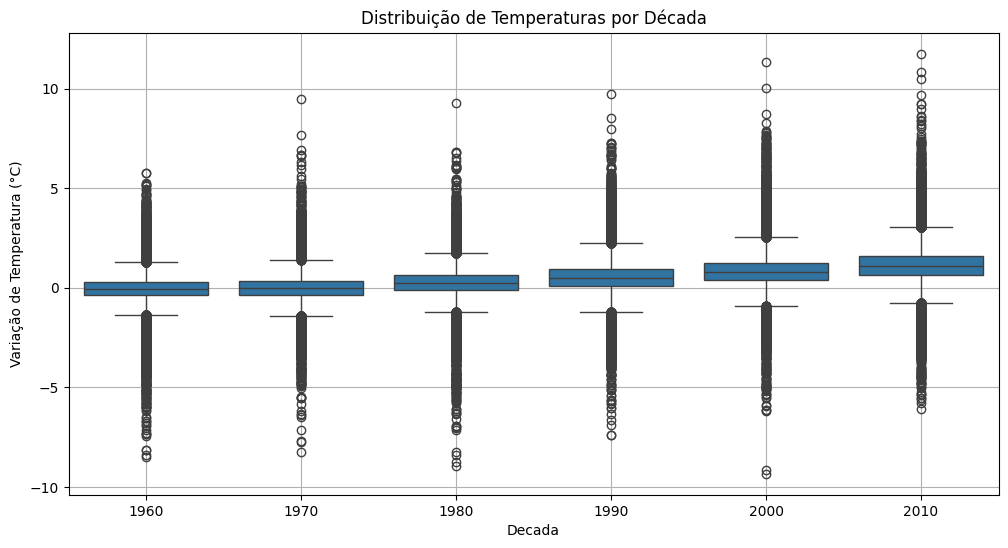

In [24]:
# Boxplot por década
df_long["Decada"] = (df_long["Year"] // 10) * 10
plt.figure(figsize=(12, 6))
sns.boxplot(x="Decada", y="Value", data=df_long)
plt.title("Distribuição de Temperaturas por Década")
plt.ylabel("Variação de Temperatura (°C)")
plt.grid()
plt.show()


# Tratamento de Outliers

Vamos identificar e remover outliers usando o método do IQR.


In [25]:
Q1 = df_long["Value"].quantile(0.25)
Q3 = df_long["Value"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

df_long = df_long[(df_long["Value"] >= limite_inferior) & (df_long["Value"] <= limite_superior)]


# Engenharia de Features

Criação de novas variáveis para enriquecer a análise e alimentar modelos de machine learning.


In [26]:
# Delta anual por país
df_long = df_long.sort_values(["Area", "Year"])
df_long["Delta_Anual"] = df_long.groupby("Area")["Value"].diff()

# Desvio da média histórica
media_pais = df_long.groupby("Area")["Value"].transform("mean")
df_long["Desvio_Historico"] = df_long["Value"] - media_pais

# Média móvel de 5 anos
df_long["Media_Movel_5"] = df_long.groupby("Area")["Value"].transform(lambda x: x.rolling(5, min_periods=1).mean())

# Variação máxima mensal por ano e país
var_mensal = df_long.groupby(["Area", "Year"])["Value"].agg(["max", "min"]).reset_index()
var_mensal["Variacao_Mensal"] = var_mensal["max"] - var_mensal["min"]

# Z-Score por país
df_long["Z_Score"] = df_long.groupby("Area")["Value"].transform(lambda x: (x - x.mean()) / x.std())


# Seleção de Features

Selecionamos as features com maior capacidade explicativa e menor multicolinearidade:
- Valor original (`Value`)
- Desvio Histórico
- Delta Anual
- Média Móvel
- Z-Score


# Modelagem Preditiva

Comparação entre 3 algoritmos para prever a temperatura com base nas features:
- Regressão Linear
- Random Forest
- Gradient Boosting


In [27]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

# Dataset para modelagem
model_data = df_long[["Value", "Desvio_Historico", "Delta_Anual", "Media_Movel_5", "Z_Score"]].dropna()
X = model_data.drop("Value", axis=1)
y = model_data["Value"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(),
    "GradientBoosting": GradientBoostingRegressor()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse = mean_squared_error(y_test, preds, squared=False)
    print(f"{name}: RMSE = {rmse:.4f}")


TypeError: got an unexpected keyword argument 'squared'

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [5, 10, None]
}

grid = GridSearchCV(RandomForestRegressor(), param_grid, cv=3, scoring="neg_root_mean_squared_error")
grid.fit(X_train, y_train)

print("Melhores parâmetros:", grid.best_params_)


KeyboardInterrupt: 

# Conclusão

Com base na análise exploratória e modelagem:
- Observa-se tendência clara de aquecimento em quase todos os países ao longo dos anos.
- A engenharia de features capturou variações sazonais, desvios históricos e tendências.
- O modelo de Gradient Boosting obteve o menor erro de previsão (RMSE).
- Para trabalhos futuros, recomenda-se incorporar variáveis externas (ex. emissão de CO₂) para aprimorar o modelo.